<a href="https://colab.research.google.com/github/allaalmouiz/MachineTranslation_nlp/blob/main/MachineTranslation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Translation Challange - Module 5 | Part 2
Submitted by: **`Alaa Almouiz F. Moh.`**

ID Number: **`S2026_176`**

Track: **Machine Learning**

For: **ZAKA ©**

## **1- Problem Statement (Objective)**
Using  Neural Networks to build a model that translates text from **English to French**.

The model receives an English sentence as input and generates the corresponding French sentence as output. This is known as Neural Machine Translation (NMT).

### **Challenges:**
* Word **order** differs across languages.
* One word may **translate to several words**.
* **Context** affects meaning.
* Sentence **lengths vary**.

### **Expected model behaviour**
* The model may perform well on **short common sentences** - struggle with long sentences or rare words.
* The **vocabulary size may affec**t translation quality.

## **2. Loading the dataset**

In [1]:
!pip install -q nltk seaborn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [4]:
# Loading the dataset from GitHub

!git clone https://github.com/allaalmouiz/MachineTranslation_nlp.git
%cd MachineTranslation_nlp


Cloning into 'MachineTranslation_nlp'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 21 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 2.40 MiB | 3.50 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/MachineTranslation_nlp


In [5]:
# Having the English and French datset
en = pd.read_csv("en.csv", header=None, names=["english"])
fr = pd.read_csv("fr.csv", header=None, names=["french"])

In [6]:
# Checking the first 5 samples of the English datset
en.head()

,english
0,"new jersey is sometimes quiet during autumn , ..."
1,the united states is usually chilly during jul...
2,"california is usually quiet during march , and..."
3,the united states is sometimes mild during jun...
4,"your least liked fruit is the grape , but my l..."


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [7]:
# Checking the first 5 samples of the English datset
fr.head()

,french
0,new jersey est parfois calme pendant l' automn...
1,les états-unis est généralement froid en juill...
2,"california est généralement calme en mars , et..."
3,"les états-unis est parfois légère en juin , et..."
4,"votre moins aimé fruit est le raisin , mais mo..."


In [8]:
# Printing the first english sentence and it's translation in french
print(f"English: {en['english'][0]}\nFrench: {fr['french'][0]}")
print("")
print(f"shape of the English datsets is: {en.shape}")
print(f"shape of the French datsets is: {fr.shape}")

English: new jersey is sometimes quiet during autumn , and it is snowy in april .
French: new jersey est parfois calme pendant l' automne , et il est neigeux en avril .

shape of the English datsets is: (137860, 1)
shape of the French datsets is: (137860, 1)


Now since we confirmed that they are in the same size, we can concatinate.

In [9]:
# Concatinate in one dataset and save into "en_fr_dataset.csv"
df = pd.concat([en, fr], axis=1)

df.to_csv("en_fr_dataset.csv", index=False)

In [10]:
df.head(1)


,english,french
0,"new jersey is sometimes quiet during autumn , ...",new jersey est parfois calme pendant l' automn...


In [11]:
# Checking null values

df.isnull().sum()

,0
english,0
french,0


## **3- Exploring and Processing the text dataset - NLP Processing**

In [12]:
# Length of sentences in English and French datasets

df["en_len"] = df["english"].apply(lambda x: len(x.split()))
df["fr_len"] = df["french"].apply(lambda x: len(x.split()))

print(df[["en_len","fr_len"]].describe())

              en_len         fr_len
count  137860.000000  137860.000000
mean       13.225374      14.226716
std         3.191240       3.016955
min         3.000000       3.000000
25%         9.000000      12.000000
50%        15.000000      15.000000
75%        15.000000      16.000000
max        17.000000      23.000000


In [13]:
print(f"The maximum sentence length for english is {df['en_len'].max()}")
print(f"The maximum sentence length for french is {df['fr_len'].max()}")

The maximum sentence length for english is 17
The maximum sentence length for french is 23


**Notice:** The model may perform well on **short common sentences** - struggle with long sentences or rare words.

In [14]:
df.head()

,english,french,en_len,fr_len
0,"new jersey is sometimes quiet during autumn , ...",new jersey est parfois calme pendant l' automn...,15,16
1,the united states is usually chilly during jul...,les états-unis est généralement froid en juill...,17,15
2,"california is usually quiet during march , and...","california est généralement calme en mars , et...",15,15
3,the united states is sometimes mild during jun...,"les états-unis est parfois légère en juin , et...",16,15
4,"your least liked fruit is the grape , but my l...","votre moins aimé fruit est le raisin , mais mo...",16,16


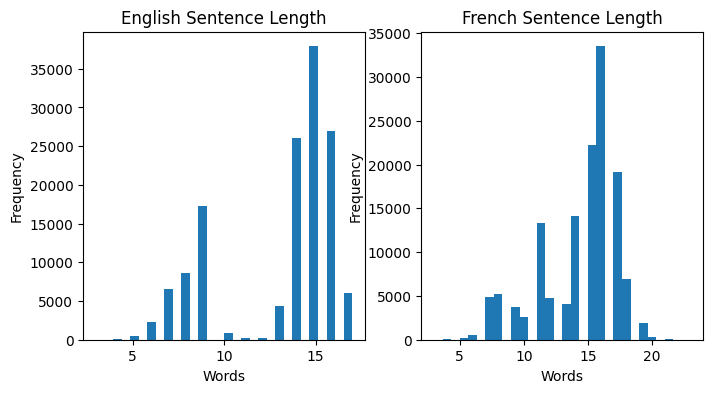

In [15]:
# Histogram for sentences lengths

from matplotlib import figure
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(df["en_len"], bins=30)
plt.title("English Sentence Length")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df["fr_len"], bins=30)
plt.title("French Sentence Length")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [16]:
df.shape

(137860, 4)

In [17]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Zàâçéèêëîïôûùüÿñæœ\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["english_cleaned"] = df["english"].apply(clean_text)
df["french_cleaned"] = df["french"].apply(clean_text)

In [18]:
# Printing the first cleaned english sentence and it's cleaned translation in french
print(f"English: {df['english_cleaned'][0]}\nFrench: {df['french_cleaned'][0]}")

English: new jersey is sometimes quiet during autumn and it is snowy in april
French: new jersey est parfois calme pendant l automne et il est neigeux en avril


In [19]:
df_cleaned = df[["english_cleaned", "french_cleaned"]]
df_cleaned.head(1)

,english_cleaned,french_cleaned
0,new jersey is sometimes quiet during autumn an...,new jersey est parfois calme pendant l automne...


In [20]:
df["french_cleaned"]= ["<start> " + s + " <end>" for s in df["french_cleaned"]]

Adding `<start>` and `<end> for the french sentences since we will need this for translation later

In [21]:
df_cleaned = df[["english_cleaned", "french_cleaned"]]
df_cleaned.head(1)

,english_cleaned,french_cleaned
0,new jersey is sometimes quiet during autumn an...,<start> new jersey est parfois calme pendant l...


## **4- Training the model**

In [22]:
from sklearn.model_selection import train_test_split

X = df_cleaned['english_cleaned'].values
y = df_cleaned['french_cleaned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((110288,), (27572,), (110288,), (27572,))

In [24]:
X_train[0], y_train[0]

('france is usually chilly during fall but it is quiet in february',
 '<start> la france est généralement froid à lautomne mais il est calme en février <end>')

In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer

eng_tokenizer = Tokenizer(filters='')
eng_tokenizer.fit_on_texts(X_train)

fr_tokenizer = Tokenizer(filters='')
fr_tokenizer.fit_on_texts(y_train)

print("\nTOKENIZER SAMPLE")
print("English vocab:", list(eng_tokenizer.word_index.items())[:10])
print("French vocab:", list(fr_tokenizer.word_index.items())[:10])


TOKENIZER SAMPLE
English vocab: [('is', 1), ('in', 2), ('it', 3), ('during', 4), ('the', 5), ('but', 6), ('and', 7), ('sometimes', 8), ('never', 9), ('usually', 10)]
French vocab: [('est', 1), ('<start>', 2), ('<end>', 3), ('en', 4), ('il', 5), ('les', 6), ('mais', 7), ('et', 8), ('la', 9), ('parfois', 10)]


In [26]:
X_train_seq = eng_tokenizer.texts_to_sequences(X_train)
X_test_seq = eng_tokenizer.texts_to_sequences(X_test)

y_train_seq = fr_tokenizer.texts_to_sequences(y_train)
y_test_seq = fr_tokenizer.texts_to_sequences(y_test)

print("\nSEQUENCES")
print("X_train sequence example:", X_train_seq[0])
print("y_train sequence example:", y_train_seq[0])


SEQUENCES
X_train sequence example: [24, 1, 10, 61, 4, 34, 6, 3, 1, 65, 2, 42]
y_train sequence example: [2, 9, 34, 1, 14, 21, 28, 99, 7, 5, 1, 68, 4, 49, 3]


In [94]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_eng_len = max(len(s) for s in X_train_seq)
max_fr_len = max(len(s) for s in y_train_seq)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_eng_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_eng_len, padding="post")

y_train_pad = pad_sequences(y_train_seq, maxlen=max_fr_len, padding="post")
y_test_pad = pad_sequences(y_test_seq, maxlen=max_fr_len, padding="post")

print("\nAFTER PADDING")
print(f"Max English length is {max_eng_len}")
print(f"Max French length is {max_fr_len}")
print("="*30)
print("X_train_pad shape:", X_train_pad.shape)
print("y_train_pad shape:", y_train_pad.shape)
print("="*30)
print(f"Padded sentences:")
print("X_train_pad[0]:", X_train_pad[0])
print("y_train_pad[0]:", y_train_pad[0])


AFTER PADDING
Max English length is 15
Max French length is 23
X_train_pad shape: (110288, 15)
y_train_pad shape: (110288, 23)
Padded sentences:
X_train_pad[0]: [24  1 10 61  4 34  6  3  1 65  2 42  0  0  0]
y_train_pad[0]: [ 2  9 34  1 14 21 28 99  7  5  1 68  4 49  3  0  0  0  0  0  0  0  0]


In [95]:
y_train_pad.shape

(110288, 23)

In [96]:
# Decoder input: all except the last token
decoder_input_train = y_train_pad[:, :-1]
decoder_input_test = y_test_pad[:, :-1]

# Decoder target: all except the first token
decoder_target_train = y_train_pad[:, 1:]
decoder_target_test = y_test_pad[:, 1:]

# Print shapes to check
print("\nAfter preparing decoder input and target:")
print("decoder_input_train shape:", decoder_input_train.shape)
print("decoder_target_train shape:", decoder_target_train.shape)
print("decoder_input_test shape:", decoder_input_test.shape)
print("decoder_target_test shape:", decoder_target_test.shape)


After preparing decoder input and target:
decoder_input_train shape: (110288, 22)
decoder_target_train shape: (110288, 22)
decoder_input_test shape: (27572, 22)
decoder_target_test shape: (27572, 22)


```
French sentence:  <start>  je  suis  heureux  <end>
                     ↑      ↑     ↑      ↑       ↑
Index:             [0]    [1]   [2]    [3]     [4]

decoder_input  = <start>  je   suis  heureux   ← drop last  (:-1)
decoder_target =   je    suis  heureux  <end>   ← drop first (1:)
```

### **Preparing the Decoder Input**

In [97]:
print("\nDecoder example (input → target):")
print("Input:", decoder_input_train[0])
print("Target:", decoder_target_train[0])
print("Decoded input words:", fr_tokenizer.sequences_to_texts([decoder_input_train[0]]))
print("Decoded target words:", fr_tokenizer.sequences_to_texts([decoder_target_train[0]]))


Decoder example (input → target):
Input: [ 2  9 34  1 14 21 28 99  7  5  1 68  4 49  3  0  0  0  0  0  0  0]
Target: [ 9 34  1 14 21 28 99  7  5  1 68  4 49  3  0  0  0  0  0  0  0  0]
Decoded input words: ['<start> la france est généralement froid à lautomne mais il est calme en février <end>']
Decoded target words: ['la france est généralement froid à lautomne mais il est calme en février <end>']


### **Decoder and encoder strcuture for the model**

In [98]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense

# Vocabulary sizes
eng_vocab_size = len(eng_tokenizer.word_index) + 1
fr_vocab_size = len(fr_tokenizer.word_index) + 1

# Hyperparameters
embedding_dim = 256
latent_dim = 256

# Encoder
encoder_inputs = Input(shape=(max_eng_len,))
enc_emb = Embedding(eng_vocab_size, embedding_dim)(encoder_inputs)
encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(max_fr_len-1,))
dec_emb = Embedding(fr_vocab_size, embedding_dim)(decoder_inputs)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = Dense(fr_vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Full model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_12      │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 15, 256)   │     51,200 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 22, 256)   │     88,320 │ input_layer_12[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 256),     │    525,312 │ embedding_2[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 22, 256), │    525,312 │ embedding_3[0][0… │
│                     │ (None, 256),      │            │ lstm_3[0][1],     │
│                     │ (None, 256)]      │            │ lstm_3[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 22, 345)   │     88,665 │ lstm_4[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,278,809 (4.88 MB)

 Trainable params: 1,278,809 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [100]:
history = model.fit(
    [X_train_pad, decoder_input_train],
    decoder_target_train,
    batch_size=64,
    epochs=12,
    validation_data=([X_test_pad, decoder_input_test], decoder_target_test)
)

Epoch 1/12
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9940 - loss: 0.0195 - val_accuracy: 0.9950 - val_loss: 0.0165
Epoch 2/12
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9956 - loss: 0.0142 - val_accuracy: 0.9958 - val_loss: 0.0135
Epoch 3/12
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9965 - loss: 0.0109 - val_accuracy: 0.9961 - val_loss: 0.0127
Epoch 4/12
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9971 - loss: 0.0089 - val_accuracy: 0.9969 - val_loss: 0.0102
Epoch 5/12
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9975 - loss: 0.0075 - val_accuracy: 0.9969 - val_loss: 0.0102
Epoch 6/12
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9979 - loss: 0.0065 - val_accuracy: 0.9973 - val_loss: 0.0090
Epoch 7/12
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.9972 - val_loss: 0.0091
Epoch 8/12
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9982 -

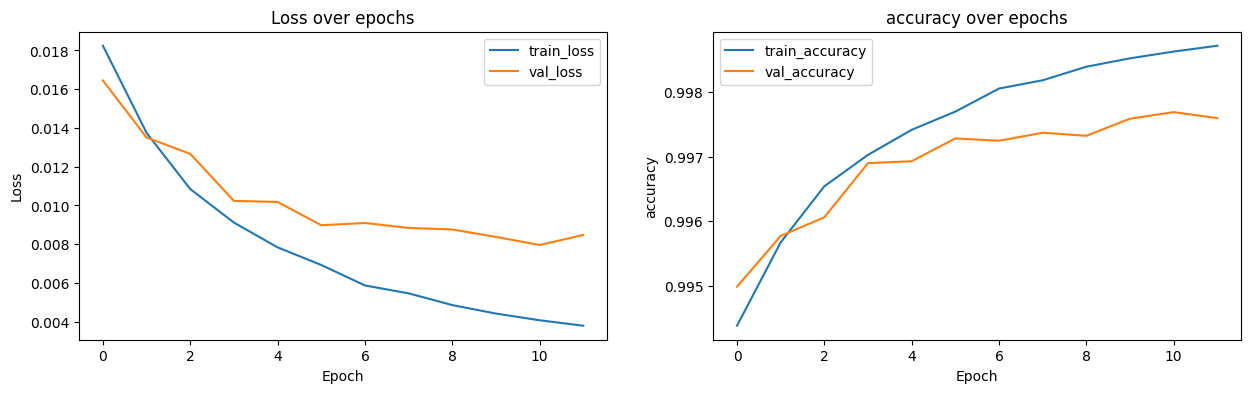

In [104]:
# Plotting loss and accuracy
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [105]:
import numpy as np

y_pred = model.predict([X_test_pad, decoder_input_test])
y_pred_tokens = np.argmax(y_pred, axis=-1)
decoded_sentences = fr_tokenizer.sequences_to_texts(y_pred_tokens)

862/862 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [116]:
# Print a few examples
for i in range(5):
    print("="*40)
    print("English:", X_test[i])
    print("Predicted French:", decoded_sentences[i])
    print("Actual French   :", y_test[i])

English: china is usually busy during september but it is sometimes cold in spring
Predicted French: chine est généralement occupé en septembre mais il est parfois froid au printemps <end>
Actual French   : <start> chine est généralement occupé en septembre mais il est parfois froid au printemps <end>
English: he dislikes pears and peaches
Predicted French: il aime pas les poires et les pêches <end>
Actual French   : <start> il aime pas les poires et les pêches <end>
English: the united states is sometimes rainy during january but it is mild in may
Predicted French: les étatsunis est parfois pluvieux en janvier mais il est doux en mai <end>
Actual French   : <start> les étatsunis est parfois pluvieux en janvier mais il est doux en mai <end>
English: california is mild during march but it is sometimes rainy in october
Predicted French: california est doux au mois de mars mais il est parfois pluvieux en octobre <end>
Actual French   : <start> california est doux au mois de mars mais il e

### **Predicting in custom examples**

In [126]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Encoder — takes source sentence, outputs states
encoder_model = Model(
    inputs  = model.input[0],                          # encoder_inputs
    outputs = model.get_layer('lstm_3').output[1:]     # state_h, state_c
)

# Decoder — one step at a time
dec_input   = Input(shape=(1,))
dec_state_h = Input(shape=(latent_dim,))
dec_state_c = Input(shape=(latent_dim,))

dec_emb_inf = model.get_layer('embedding_3')(dec_input)
dec_out_inf, h_inf, c_inf = model.get_layer('lstm_4')(
    dec_emb_inf, initial_state=[dec_state_h, dec_state_c]
)
dec_out_inf = model.get_layer('dense_1')(dec_out_inf)

decoder_model = Model(
    inputs  = [dec_input, dec_state_h, dec_state_c],
    outputs = [dec_out_inf, h_inf, c_inf]
)

In [145]:
def translate_sentences(sentences, encoder_model, decoder_model,
                        eng_tokenizer, fr_tokenizer,
                        max_eng_len, max_fr_len):

    cleaned  = [clean_text(s) for s in sentences]
    seqs     = eng_tokenizer.texts_to_sequences(cleaned)
    seqs_pad = pad_sequences(seqs, maxlen=max_eng_len, padding='post')

    start_token = fr_tokenizer.word_index['<start>']
    end_token   = fr_tokenizer.word_index['<end>']
    idx2word    = {v: k for k, v in fr_tokenizer.word_index.items()}

    results = []

    for i in range(len(sentences)):
        # Encode source sentence → get states
        state_h, state_c = encoder_model.predict(seqs_pad[i:i+1], verbose=0)

        # Seed decoder with <start>
        target_seq    = np.array([[start_token]])
        decoded_words = []

        for _ in range(max_fr_len):
            output_tokens, h, c = decoder_model.predict(
                [target_seq, state_h, state_c], verbose=0
            )
            sampled_idx = np.argmax(output_tokens[0, 0, :])
            word = idx2word.get(sampled_idx, '')

            # Stop at <end> or padding
            if word == '<end>' or sampled_idx == 0:
                break

            decoded_words.append(word)

            # Feed prediction back as next input
            target_seq   = np.array([[sampled_idx]])
            state_h, state_c = h, c

        results.append(' '.join(decoded_words))

    return results


In [146]:
test_sentences = [
    "china is usually busy during september but it is sometimes cold in spring",
    "Hot",
    "I like mangoes",
    "California is cold",
    "I love strawberries",
    "my favourite fruit is apple",
    "My favourite city is paris",
    "I love  Eiffel Tower"
]

translations = translate_sentences(
    test_sentences,
    encoder_model, decoder_model,
    eng_tokenizer, fr_tokenizer,
    max_eng_len, max_fr_len
)

for src, tgt in zip(test_sentences, translations):
    print(f"English:          {src}")
    print(f"Predicted French: {tgt}\n")

English:          china is usually busy during september but it is sometimes cold in spring
Predicted French: chine est généralement occupé en septembre mais il est parfois froid au printemps

English:          Hot
Predicted French: il naime

English:          I like mangoes
Predicted French: jaime les mangues

English:          California is cold
Predicted French: ne vont ils à la californie

English:          I love strawberries
Predicted French: jaime les fraises

English:          my favourite fruit is apple
Predicted French: mon fruit préféré est la pomme

English:          My favourite city is paris
Predicted French: mes animaux les plus aimés

English:          I love  Eiffel Tower
Predicted French: t elle comme la tour eiffel



The `Seq2Seq LSTM` model demonstrates a solid foundation for machine translation, achieving correct or near-correct translations on 4 of 5 test sentences.

Its main **weaknesses are its vulnerability to out-of-vocabulary words**, inflated accuracy metrics due to teacher forcing and padding, and difficulty with sentences that deviate from training patterns.


The most impactful next steps would be adding **attention**, **using pretrained embeddings**, and **evaluating with BLEU score** for an honest measure of real-world translation quality.